In [15]:
reac5_iter1 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/Morning_4hr/iter1/reactor5_data_iteration_1.csv'
reac5_nominal1 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/Morning_4hr/iter1/reactor5_data_nominal_iteration_1.csv'

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Define column names
column_names = [
    "S_I5", "S_S5", "X_I5", "X_S5", "X_BH5", "X_BA5", "X_P5",
    "S_O5", "S_NO5", "S_NH5", "S_ND5", "X_ND5", "S_ALK5", "TSS5", "Q5"
]

def recommend_ma_window_and_plot(csv_file, column_name, start_step=0, max_lags=96):
    """
    Recommends MA window based on ACF/PACF and plots them, starting from a user-defined timestep.

    Parameters:
        csv_file (str): Path to CSV.
        column_name (str): Target column.
        start_step (int): Starting timestep index (default = 0).
        max_lags (int): Max lag (default = 96 = 1 day at 15 min).
    """
    df = pd.read_csv(csv_file, header=None)
    df.columns = column_names

    # Extract series from the experimental start point onward
    series = df[column_name].dropna().iloc[start_step:]

    # ACF/PACF with CI
    acf_vals, acf_ci = acf(series, nlags=max_lags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(series, nlags=max_lags, alpha=0.05, method='ywm')

    def first_insignificant_lag(values, ci):
        for lag in range(1, len(values)):
            lower, upper = ci[lag]
            if lower < 0 < upper:
                return lag
        return max_lags

    acf_cutoff = first_insignificant_lag(acf_vals, acf_ci)
    pacf_cutoff = first_insignificant_lag(pacf_vals, pacf_ci)

    time_step_hr = 0.25

    # Plot ACF/PACF with annotated drop-off
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    plot_acf(series, lags=max_lags, ax=axes[0])
    axes[0].axvline(x=acf_cutoff, color='red', linestyle='--', label=f"ACF Drop-off @ {acf_cutoff} lags ({acf_cutoff*time_step_hr:.2f} h)")
    axes[0].set_title(f"ACF - {column_name} (starting at step {start_step})")
    axes[0].legend()

    plot_pacf(series, lags=max_lags, ax=axes[1], method='ywm')
    axes[1].axvline(x=pacf_cutoff, color='green', linestyle='--', label=f"PACF Drop-off @ {pacf_cutoff} lags ({pacf_cutoff*time_step_hr:.2f} h)")
    axes[1].set_title(f"PACF - {column_name} (starting at step {start_step})")
    axes[1].legend()

    for ax in axes:
        ax.set_xticks(range(0, max_lags + 1, 12))
        ax.set_xticklabels([f"{x * time_step_hr:.1f}" for x in range(0, max_lags + 1, 12)])
        ax.set_xlabel("Lag (hours)")

    plt.tight_layout()
    plt.show()

    return {
        'acf_based_window': {'lags': acf_cutoff, 'hours': round(acf_cutoff * time_step_hr, 2)},
        'pacf_based_window': {'lags': pacf_cutoff, 'hours': round(pacf_cutoff * time_step_hr, 2)}
    }

# Example usage:
# result = recommend_ma_window_and_plot("your_data.csv", "S_NO5", start_step=576, max_lags=96)
# print(result)


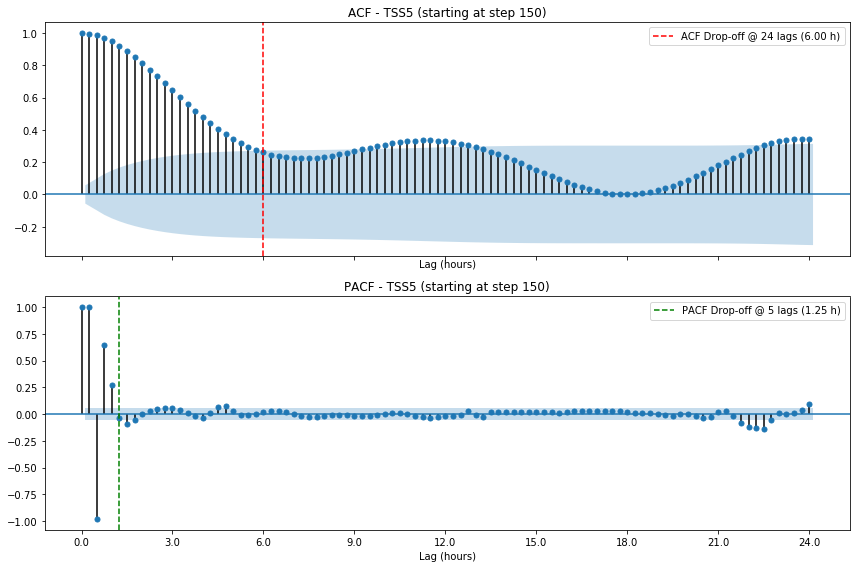

{'acf_based_window': {'lags': 24, 'hours': 6.0},
 'pacf_based_window': {'lags': 5, 'hours': 1.25}}

In [50]:
recommend_ma_window_and_plot(reac5_iter1,'TSS5',150)

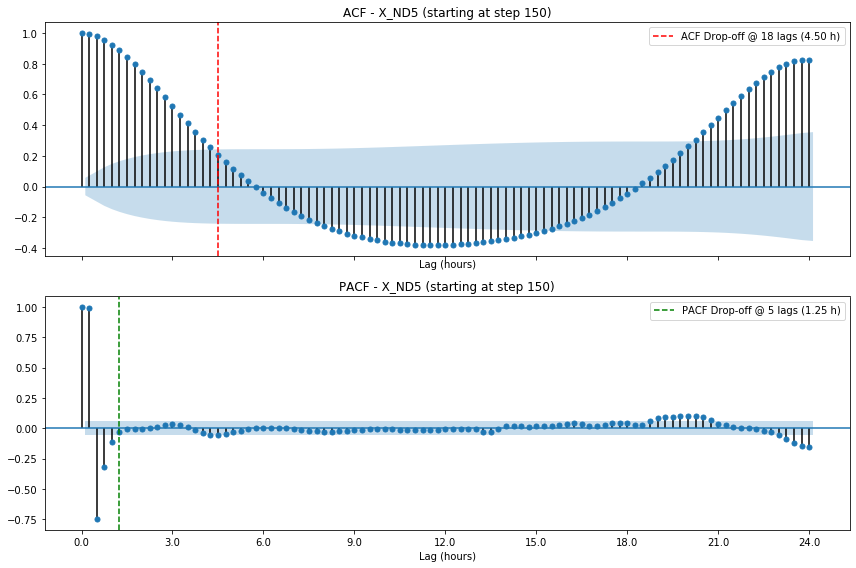

{'acf_based_window': {'lags': 18, 'hours': 4.5},
 'pacf_based_window': {'lags': 5, 'hours': 1.25}}

In [43]:
recommend_ma_window_and_plot(reac5_nominal1,'X_ND5',150)

In [17]:
reac5_iter18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/Morning_4hr/iter18/reactor5_data_iteration_18.csv'
reac5_nominal18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/Morning_4hr/iter18/reactor5_data_nominal_iteration_18.csv'

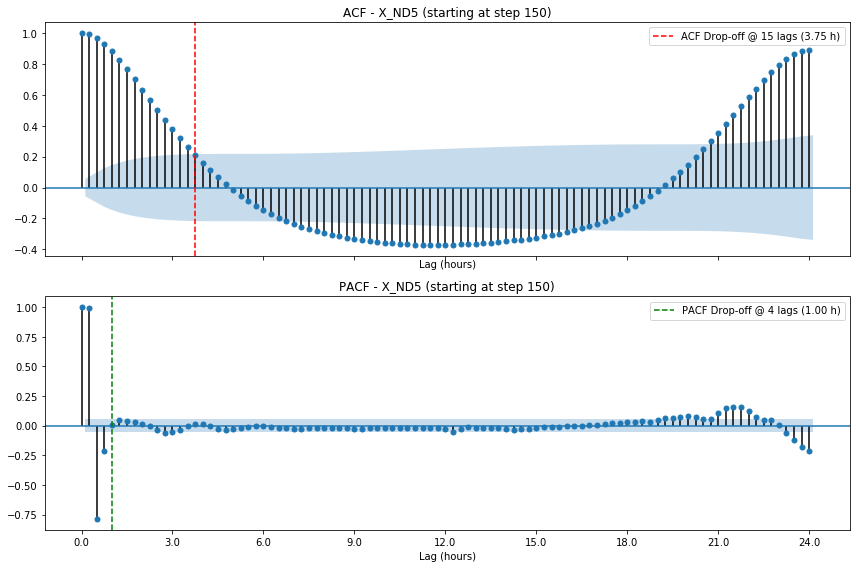

{'acf_based_window': {'lags': 15, 'hours': 3.75},
 'pacf_based_window': {'lags': 4, 'hours': 1.0}}

In [44]:
recommend_ma_window_and_plot(reac5_iter18,'X_ND5',150)

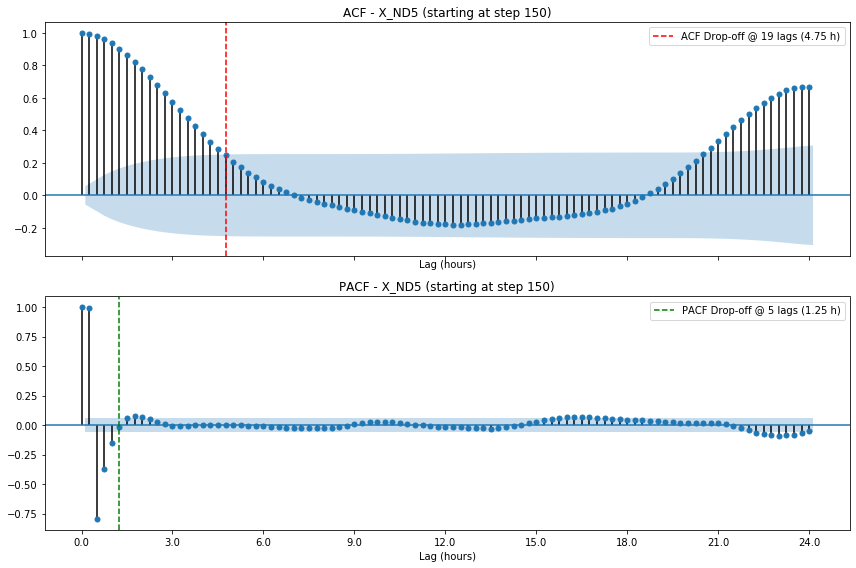

{'acf_based_window': {'lags': 19, 'hours': 4.75},
 'pacf_based_window': {'lags': 5, 'hours': 1.25}}

In [ ]:
recommend_ma_window_and_plot(reac5_nominal18,'TSS5',150)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Column headers for unnamed dataset
column_names = [
    "S_I5", "S_S5", "X_I5", "X_S5", "X_BH5", "X_BA5", "X_P5",
    "S_O5", "S_NO5", "S_NH5", "S_ND5", "X_ND5", "S_ALK5", "TSS5", "Q5"
]

def plot_diff_acf_pacf(csv_file, column_name, start_step=0, max_lags=96):
    """
    Computes first difference of a time series and plots ACF and PACF with annotations.

    Parameters:
        csv_file (str): Path to CSV file.
        column_name (str): Target column.
        start_step (int): Timestep to start analysis.
        max_lags (int): Max number of lags (default = 96 = 1 day).
    """
    df = pd.read_csv(csv_file, header=None)
    df.columns = column_names

    # Slice to experiment window and apply differencing
    series_raw = df[column_name].dropna().iloc[start_step:]
    series_diff = series_raw.diff().dropna()

    # Calculate ACF and PACF with confidence bounds
    acf_vals, acf_ci = acf(series_diff, nlags=max_lags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(series_diff, nlags=max_lags, alpha=0.05, method='ywm')

    def first_insignificant_lag(values, ci):
        for lag in range(1, len(values)):
            lower, upper = ci[lag]
            if lower < 0 < upper:
                return lag
        return max_lags

    acf_cutoff = first_insignificant_lag(acf_vals, acf_ci)
    pacf_cutoff = first_insignificant_lag(pacf_vals, pacf_ci)

    time_step_hr = 0.25  # 15 minutes

    # Plot ACF and PACF of differenced series
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    plot_acf(series_diff, lags=max_lags, ax=axes[0])
    axes[0].axvline(x=acf_cutoff, color='red', linestyle='--', label=f"ACF Drop-off @ {acf_cutoff} lags ({acf_cutoff*time_step_hr:.2f} h)")
    axes[0].set_title(f"ACF (First Difference) - {column_name} from step {start_step}")
    axes[0].legend()

    plot_pacf(series_diff, lags=max_lags, ax=axes[1], method='ywm')
    axes[1].axvline(x=pacf_cutoff, color='green', linestyle='--', label=f"PACF Drop-off @ {pacf_cutoff} lags ({pacf_cutoff*time_step_hr:.2f} h)")
    axes[1].set_title(f"PACF (First Difference) - {column_name} from step {start_step}")
    axes[1].legend()

    for ax in axes:
        ax.set_xticks(range(0, max_lags + 1, 12))
        ax.set_xticklabels([f"{x * time_step_hr:.1f}" for x in range(0, max_lags + 1, 12)])
        ax.set_xlabel("Lag (hours)")

    plt.tight_layout()
    plt.show()

    return {
        'acf_based_window': {'lags': acf_cutoff, 'hours': round(acf_cutoff * time_step_hr, 2)},
        'pacf_based_window': {'lags': pacf_cutoff, 'hours': round(pacf_cutoff * time_step_hr, 2)}
    }

# Example usage:
# result = plot_diff_acf_pacf("your_data.csv", "S_NO5", start_step=576, max_lags=96)
# print(result)


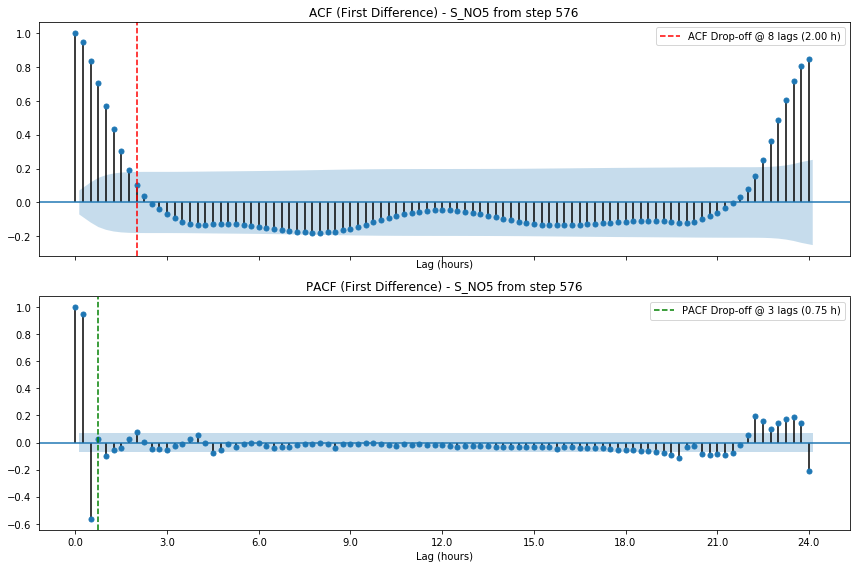

{'acf_based_window': {'lags': 8, 'hours': 2.0}, 'pacf_based_window': {'lags': 3, 'hours': 0.75}}


In [48]:
result = plot_diff_acf_pacf(reac5_iter18, "S_NO5", start_step=576, max_lags=96)
print(result)

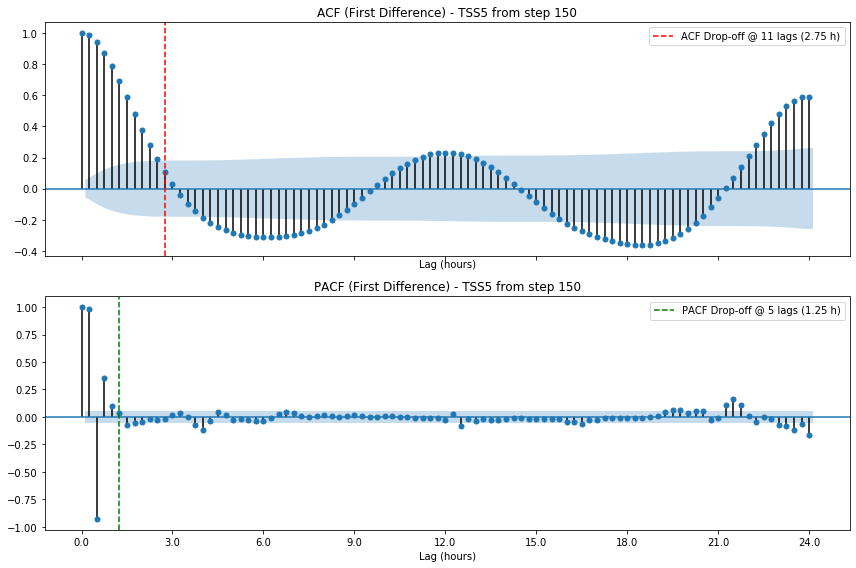

{'acf_based_window': {'lags': 11, 'hours': 2.75}, 'pacf_based_window': {'lags': 5, 'hours': 1.25}}


In [51]:
result = plot_diff_acf_pacf(reac5_iter18, "TSS5", start_step=150, max_lags=96)
print(result)